# CAB420, Practical 1 - Question 1 Template
## Linear Regression

Using the dataset from Problem 1, split the data into training, validation and testing as follows:
* Training: All data from the years 2014-2016
* Validation: All data from 2017
* Training: All data from 2018

Develop a regression model to predict one of the cycleway data series in your dataset. In developing this model you should:
* Initially, use all weather data (temperature, rainfall and solar exposure) and all other data series for a particular counter type (i.e. if you’re predicting cyclists inbound for a counter, use all other cyclist inbound counters)
* Use p-values, qqplots, and performance on the validation set to remove terms and improve the model.

When you have finished refining the model, evaluate it on test set, and compare the Root Mean Squared Error (RMSE) for the training, validation and test sets.

In training the model, you will need to ensure that you have no samples (i.e. rows) with missing data. As such, you should remove samples with missing data from the dataset before training and evaluating the model. This may also mean that you have to remove some columns that contain large amounts of missing data.

### Relevant Examples

The first linear regression example, ``CAB420_Regression_Example_1_Linear_Regression.ipynb`` is a useful starting point here.

### Suggested Packages

The following packages are suggested, however there are many ways to approach things in python, if you'd rather use different pacakges that's cool too.

In [1]:
# numpy handles pretty much anything that is a number/vector/matrix/array
import numpy as np
# pandas handles dataframes
import pandas as pd
# matplotlib emulates Matlabs plotting functionality
import matplotlib.pyplot as plt
# seaborn is another good plotting library. In particular, I like it for heatmaps (https://seaborn.pydata.org/generated/seaborn.heatmap.html)
import seaborn as sns;
# stats models is a package that is going to perform the regression analysis
from statsmodels import api as sm
from scipy import stats
from sklearn.metrics import mean_squared_error
# os allows us to manipulate variables on out local machine, such as paths and environment variables
import os
# self explainatory, dates and times
from datetime import datetime, date
# a helper package to help us iterate over objects
import itertools

### Step 1: Load the data
This may be the data you created in Q1, or the pre-baked merged data.

Use pandas and the read_csv function to load the data. It is suggested you inspect the data after loading (print some of it, use the ``head()`` function, possibly plot some series) as a sanity check.

In [2]:
combined = pd.read_csv('combined.csv')
combined['Date']= pd.to_datetime(combined['Date'], format="%d/%m/%Y")
combined.head()

,Date,BicenntenialBikeway,BicentennialBikewayPedestriansInbound,BicentennialBikewayPedestriansOutbound,BicentennialBikewayCyclistsInbound,BicentennialBikewayCyclistsOutbound,BishopStreetPedestriansInbound,BishopStreetPedestriansOutbound,BishopStreetCyclistsInbound,BishopStreetCyclistsOutbound,...,StoryBridgeWestPedestrianInbound,StoryBridgeWestPedestrianOutbound,StoryBridgeWestCyclistsInbound,StoryBridgeWestCyclistsOutbound,BureauOfMeteorologyStationNumber,RainfallAmount_millimetres_,PeriodOverWhichRainfallWasMeasured_days_,MaximumTemperature_DegreeC_,DaysOfAccumulationOfMaximumTemperature,DailyGlobalSolarExposure_MJ_m_m_
0,2014-01-01,3333.0,866.0,1326.0,569.0,572.0,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,40913,0.0,1.0,30.6,1.0,31.2
1,2014-01-02,4863.0,1372.0,2133.0,658.0,700.0,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,40913,0.0,1.0,31.8,1.0,23.4
2,2014-01-03,3905.0,1163.0,1867.0,463.0,412.0,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,40913,1.0,1.0,34.5,1.0,29.6
3,2014-01-04,3066.0,770.0,1522.0,410.0,364.0,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,40913,0.0,1.0,38.7,1.0,30.5
4,2014-01-05,4550.0,1153.0,2102.0,654.0,641.0,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,40913,0.0,1.0,33.6,1.0,15.7


### Step 2: Filter the data

As you inspect the data, you may see some series have fewer samples than others. Trying to find rows that have all data series may lead to having too little data for analysis. A suggested approach is:
* Remove columns that have too many missin values. Use the ``dropna()`` function while setting ``axis=1`` and a threshold, such that only columns with threshold valid values or more are retained (a suggested value for threshold is about 1500, i.e. if any more than about 300 values are missing, the column should be removed).
* Now, remove the other rows that have missing values. Here, you could use ``dropna()`` operating over the rows (i.e. ``axis=0``).

In [16]:
threshold = combined.shape[0] - 300
# drop columns with lots of missing values
combined_filtered = combined.dropna(axis=1, thresh=threshold)
print(combined_filtered.shape)

print(combined_filtered.shape)

print(combined_filtered.head())
combined_filtered = combined_filtered.dropna(axis=0)
print('Final dataset shape = {}'.format(combined_filtered.shape))

(1826, 26)
(1826, 26)
        Date  BicenntenialBikeway  BicentennialBikewayPedestriansInbound  \
0 2014-01-01               3333.0                                  866.0   
1 2014-01-02               4863.0                                 1372.0   
2 2014-01-03               3905.0                                 1163.0   
3 2014-01-04               3066.0                                  770.0   
4 2014-01-05               4550.0                                 1153.0   

   BicentennialBikewayPedestriansOutbound  BicentennialBikewayCyclistsInbound  \
0                                  1326.0                               569.0   
1                                  2133.0                               658.0   
2                                  1867.0                               463.0   
3                                  1522.0                               410.0   
4                                  2102.0                               654.0   

   BicentennialBikewayCyclistsOutb

In [17]:
combined_filtered.head()

,Date,BicenntenialBikeway,BicentennialBikewayPedestriansInbound,BicentennialBikewayPedestriansOutbound,BicentennialBikewayCyclistsInbound,BicentennialBikewayCyclistsOutbound,NorthBrisbaneBikewayMannParkWindsorPedestrianInbound,NorthBrisbaneBikewayMannParkWindsorPedestrianOutbound,NorthBrisbaneBikewayMannParkWindsorCyclistsInbound,SchulzCanalBridgePedestriansInbound,...,StoryBridgeEastCyclistsOutbound,StoryBridgeWestPedestrianInbound,StoryBridgeWestPedestrianOutbound,StoryBridgeWestCyclistsInbound,BureauOfMeteorologyStationNumber,RainfallAmount_millimetres_,PeriodOverWhichRainfallWasMeasured_days_,MaximumTemperature_DegreeC_,DaysOfAccumulationOfMaximumTemperature,DailyGlobalSolarExposure_MJ_m_m_
169,2014-06-19,4223.0,1630.0,1900.0,360.0,333.0,0.0,0.0,0.0,22.0,...,0.0,0.0,0.0,0.0,40913,0.0,1.0,20.3,1.0,8.0
170,2014-06-20,3619.0,1170.0,1586.0,460.0,403.0,0.0,0.0,0.0,21.0,...,0.0,0.0,0.0,0.0,40913,5.8,1.0,22.5,1.0,9.1
171,2014-06-21,4423.0,1289.0,1847.0,645.0,642.0,0.0,0.0,0.0,28.0,...,0.0,0.0,0.0,0.0,40913,0.0,1.0,25.6,1.0,12.9
172,2014-06-22,5023.0,1542.0,2126.0,720.0,635.0,0.0,0.0,0.0,26.0,...,0.0,0.0,0.0,0.0,40913,5.2,1.0,24.2,1.0,13.0
173,2014-06-23,5329.0,1862.0,2180.0,656.0,631.0,0.0,0.0,0.0,23.0,...,0.0,0.0,0.0,0.0,40913,0.2,1.0,24.1,1.0,13.6


In [18]:
combined_filtered.dropna()

,Date,BicenntenialBikeway,BicentennialBikewayPedestriansInbound,BicentennialBikewayPedestriansOutbound,BicentennialBikewayCyclistsInbound,BicentennialBikewayCyclistsOutbound,NorthBrisbaneBikewayMannParkWindsorPedestrianInbound,NorthBrisbaneBikewayMannParkWindsorPedestrianOutbound,NorthBrisbaneBikewayMannParkWindsorCyclistsInbound,SchulzCanalBridgePedestriansInbound,...,StoryBridgeEastCyclistsOutbound,StoryBridgeWestPedestrianInbound,StoryBridgeWestPedestrianOutbound,StoryBridgeWestCyclistsInbound,BureauOfMeteorologyStationNumber,RainfallAmount_millimetres_,PeriodOverWhichRainfallWasMeasured_days_,MaximumTemperature_DegreeC_,DaysOfAccumulationOfMaximumTemperature,DailyGlobalSolarExposure_MJ_m_m_
169,2014-06-19,4223.0,1630.0,1900.0,360.0,333.0,0.0,0.0,0.0,22.0,...,0.0,0.0,0.0,0.0,40913,0.0,1.0,20.3,1.0,8.0
170,2014-06-20,3619.0,1170.0,1586.0,460.0,403.0,0.0,0.0,0.0,21.0,...,0.0,0.0,0.0,0.0,40913,5.8,1.0,22.5,1.0,9.1
171,2014-06-21,4423.0,1289.0,1847.0,645.0,642.0,0.0,0.0,0.0,28.0,...,0.0,0.0,0.0,0.0,40913,0.0,1.0,25.6,1.0,12.9
172,2014-06-22,5023.0,1542.0,2126.0,720.0,635.0,0.0,0.0,0.0,26.0,...,0.0,0.0,0.0,0.0,40913,5.2,1.0,24.2,1.0,13.0
173,2014-06-23,5329.0,1862.0,2180.0,656.0,631.0,0.0,0.0,0.0,23.0,...,0.0,0.0,0.0,0.0,40913,0.2,1.0,24.1,1.0,13.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1821,2018-12-27,3489.0,584.0,534.0,1172.0,1199.0,176.0,115.0,23.0,36.0,...,912.0,222.0,276.0,91.0,40913,0.0,1.0,29.5,1.0,29.7
1822,2018-12-28,3521.0,566.0,537.0,1194.0,1224.0,164.0,138.0,23.0,22.0,...,1008.0,228.0,300.0,104.0,40913,0.0,1.0,29.7,1.0,28.6
1823,2018-12-29,3480.0,557.0,527.0,1159.0,1237.0,131.0,70.0,20.0,28.0,...,951.0,217.0,241.0,100.0,40913,0.0,1.0,30.5,1.0,29.8
1824,2018-12-30,3501.0,598.0,531.0,1234.0,1138.0,146.0,116.0,32.0,23.0,...,905.0,212.0,263.0,93.0,40913,0.0,1.0,30.6,1.0,27.9


### Step 3: Split into Train, Validation and Test Splits

You can split the data now. Be sure to check dataset size after splitting to make sure that you have datasets of roughly the size you expect.

As part of this you should also pull out your X and Y data, i.e. your predictors and response.

You could also visualise some of this data, and aspects such as:
* Correlation between predictors and the response
* Correlation between pairs of predictors

In [19]:
train = combined_filtered[combined_filtered.Date < datetime(year=2017, month=1, day=1)]
val = combined_filtered[((combined_filtered.Date >= datetime(year=2017, month=1, day=1)) &
                        (combined_filtered.Date < datetime(year=2018, month=1, day=1)))]
test = combined_filtered[((combined_filtered.Date >= datetime(year=2018, month=1, day=1)) &
                          (combined_filtered.Date < datetime(year=2019, month=1, day=1)))]
print('num train = {}'.format(train.shape[0]))
print('val train = {}'.format(val.shape[0]))
print('test train = {}'.format(test.shape[0]))

num train = 888
val train = 276
test train = 258


### Step 4: Create the Model

Using the X and Y arrays you created above, fit a regression model. 

Explore the outputs you get from the model, including:
* The resultant model, including coefficients, p-values, and $R^2$
* A QQ-Plot, to see if assumptions around residuals hold

In [20]:
X_bom = ['RainfallAmount_millimetres_',
         'DailyGlobalSolarExposure_MJ_m_m_',
         'MaximumTemperature_DegreeC_']

# want to use all variables cyclist inbound variables
X_bcc = [x for x in train.columns.values if 'CyclistsInbound' in x]
print(X_bcc)
# remove the response variable from here
X_bcc.remove('BicentennialBikewayCyclistsInbound')
# combine this list of variables together by just extending the
# BOM data with the BCC data
X_variables = X_bom + X_bcc
Y_variable = 'BicentennialBikewayCyclistsInbound'
Y_train = np.array(train[Y_variable], dtype=np.float64)
X_train = np.array(train[X_variables], dtype=np.float64)
# want to add a constant to the model (the y-axis intercept)
X_train = sm.add_constant(X_train)

Y_val = np.array(val[Y_variable], dtype=np.float64)
X_val = np.array(val[X_variables], dtype=np.float64)
X_val = sm.add_constant(X_val)

Y_test = np.array(test[Y_variable], dtype=np.float64)
X_test = np.array(test[X_variables], dtype=np.float64)
X_test = sm.add_constant(X_test)

['BicentennialBikewayCyclistsInbound', 'NorthBrisbaneBikewayMannParkWindsorCyclistsInbound', 'SchulzCanalBridgeCyclistsInbound', 'StoryBridgeEastCyclistsInbound', 'StoryBridgeWestCyclistsInbound']


### Step 5: Refine the Model, and Evaluate the results

Based on model outputs and other data such as correlation, try to improve the model.

Remove terms that look unhelpful. After a term is removed, evaluate the model on the validation and testing sets.

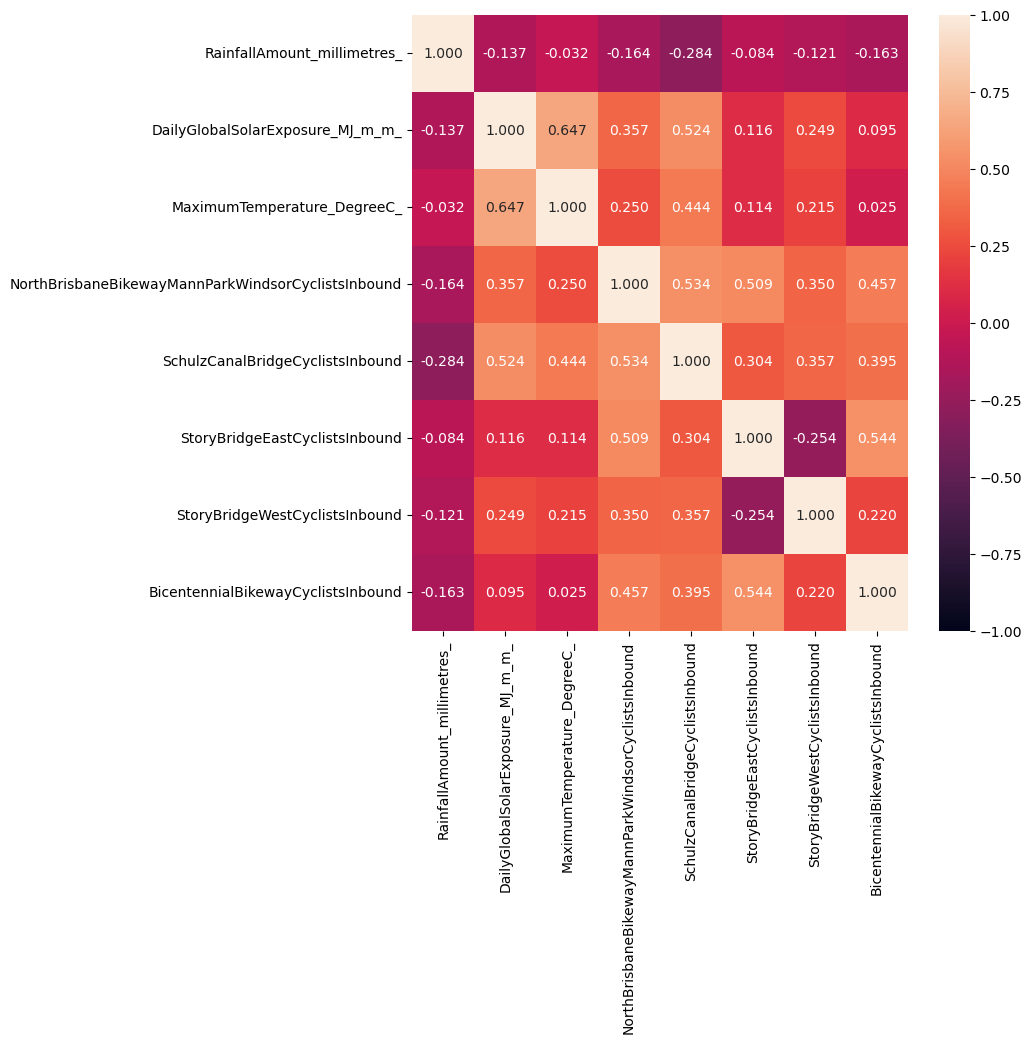

In [21]:
all_variables = X_variables + ['BicentennialBikewayCyclistsInbound']
corr_coeffs = train[all_variables].corr()
fig, ax = plt.subplots(figsize=(8,8))
ax = sns.heatmap(corr_coeffs, annot=True, fmt="1.3f", vmin=-1.0, vmax=1.0)

Model 1 RMSE = 623.37917393607
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.474
Model:                            OLS   Adj. R-squared:                  0.469
Method:                 Least Squares   F-statistic:                     113.1
Date:                Mon, 23 Feb 2026   Prob (F-statistic):          4.59e-118
Time:                        07:52:55   Log-Likelihood:                -6899.6
No. Observations:                 888   AIC:                         1.382e+04
Df Residuals:                     880   BIC:                         1.385e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        739.2276

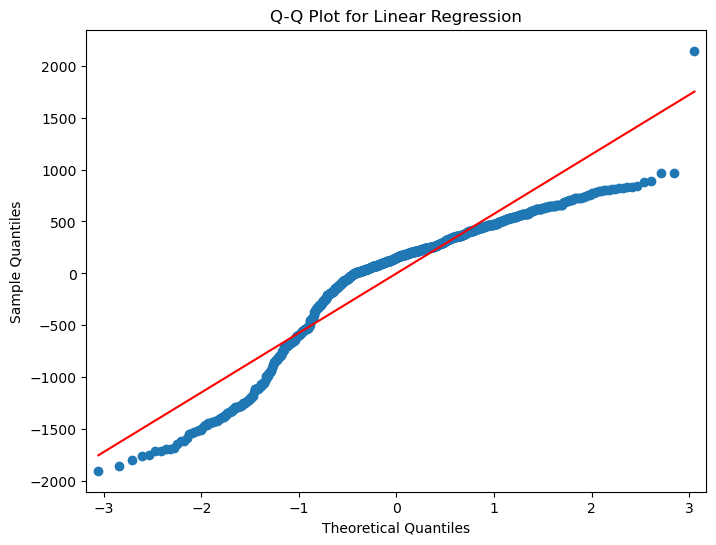

Text(0, 0.5, 'Residuals')

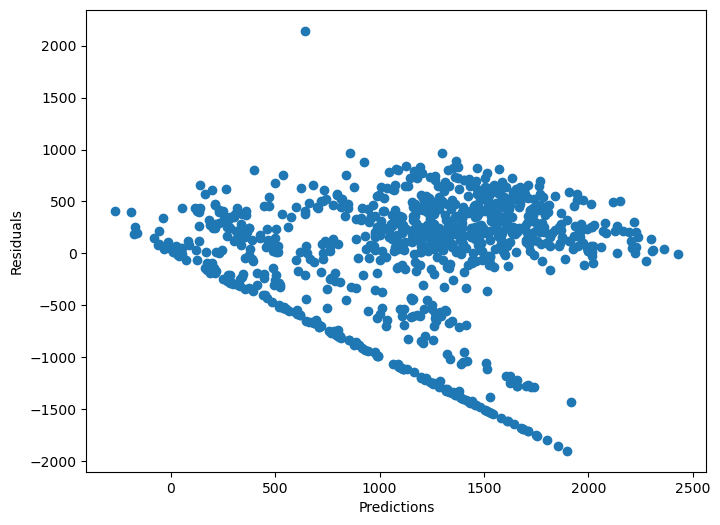

In [22]:
# create the linear model
model = sm.OLS(Y_train, X_train)
# fit the model
model_1_fit = model.fit()
pred = model_1_fit.predict(X_val)
print('Model 1 RMSE = {}'.format(
  np.sqrt(mean_squared_error(Y_val, model_1_fit.predict(X_val)))))
print(model_1_fit.summary())
print(model_1_fit.params)
fig, ax = plt.subplots(figsize=(8,6))
sm.qqplot(model_1_fit.resid, ax=ax, line='s')
plt.title('Q-Q Plot for Linear Regression')
plt.show()
fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(model_1_fit.predict(X_train), model_1_fit.resid)
ax.set_xlabel('Predictions')
ax.set_ylabel('Residuals')

[[ 1.         -0.1373654  -0.03216845 -0.16416081 -0.28375855 -0.08392224
  -0.12134364 -0.16317026]
 [-0.1373654   1.          0.64749344  0.35713766  0.52359272  0.1162428
   0.24915125  0.09517715]
 [-0.03216845  0.64749344  1.          0.25038631  0.44445062  0.11422163
   0.21496214  0.02452469]
 [-0.16416081  0.35713766  0.25038631  1.          0.53424962  0.5092007
   0.34952993  0.45741757]
 [-0.28375855  0.52359272  0.44445062  0.53424962  1.          0.30354061
   0.35673773  0.39493691]
 [-0.08392224  0.1162428   0.11422163  0.5092007   0.30354061  1.
  -0.25427468  0.54449222]
 [-0.12134364  0.24915125  0.21496214  0.34952993  0.35673773 -0.25427468
   1.          0.22037637]
 [-0.16317026  0.09517715  0.02452469  0.45741757  0.39493691  0.54449222
   0.22037637  1.        ]]


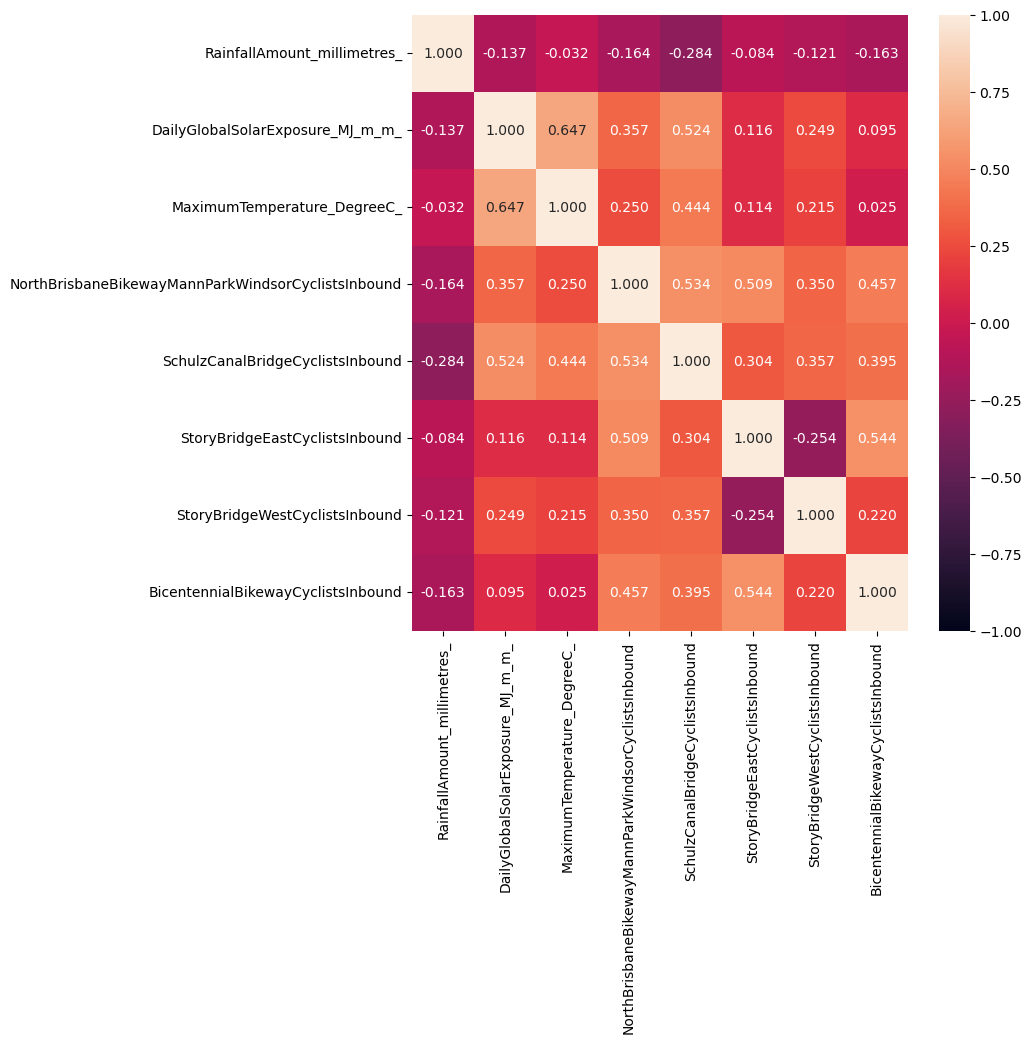

In [23]:
fig, ax = plt.subplots(figsize=(8,8))
ax = sns.heatmap(corr_coeffs, annot=True, fmt="1.3f", vmin=-1.0, vmax=1.0)
print(np.array(corr_coeffs))

In [24]:
to_remove = [X_variables[0]]
print('Variables to remove -> {}'.format(to_remove[0]))
train = train.drop(X_variables[0], axis=1)
# also want to remove these variable names from the X_variable list
X_variables.remove(to_remove[0])
print(X_variables)
# now lets create a new model and perform regression on that
X_train = np.array(train[X_variables], dtype=np.float64)

# want to add a constant to the model (the y-axis intercept)
X_train = sm.add_constant(X_train)
# also creating validation and testing data
Y_val = np.array(val[Y_variable], dtype=np.float64)
X_val = np.array(val[X_variables], dtype=np.float64)
X_val = sm.add_constant(X_val)
Y_test = np.array(test[Y_variable], dtype=np.float64)
X_test = np.array(test[X_variables], dtype=np.float64)
X_test = sm.add_constant(X_test)

# now make the model and fit it
model_2 = sm.OLS(Y_train, X_train)
# fit the model without any regularisation
model_2_fit = model_2.fit()
pred = model_2_fit.predict(X_val)
print('Model 1 RMSE = {}'.format(
  np.sqrt(mean_squared_error(Y_val, model_2_fit.predict(X_val)))))
print(model_2_fit.summary())
print(model_2_fit.params)

Variables to remove -> RainfallAmount_millimetres_
['DailyGlobalSolarExposure_MJ_m_m_', 'MaximumTemperature_DegreeC_', 'NorthBrisbaneBikewayMannParkWindsorCyclistsInbound', 'SchulzCanalBridgeCyclistsInbound', 'StoryBridgeEastCyclistsInbound', 'StoryBridgeWestCyclistsInbound']
Model 1 RMSE = 622.6997548236517
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.473
Model:                            OLS   Adj. R-squared:                  0.469
Method:                 Least Squares   F-statistic:                     131.6
Date:                Mon, 23 Feb 2026   Prob (F-statistic):          8.12e-119
Time:                        07:53:39   Log-Likelihood:                -6900.4
No. Observations:                 888   AIC:                         1.381e+04
Df Residuals:                     881   BIC:                         1.385e+04
Df Model:                           6                     

In [25]:
to_remove = [X_variables[0]]
print('Variable to remove -> {}'.format(to_remove[0]))
train = train.drop([X_variables[0]], axis=1)
# also want to remove these variable names from the X_variable list
X_variables.remove(to_remove[0])
print(X_variables)
# now lets create a new model and perform regression on that
X_train = np.array(train[X_variables], dtype=np.float64)
# want to add a constant to the model (the y-axis intercept)
X_train = sm.add_constant(X_train)
# also creating validation and testing data
Y_val = np.array(val[Y_variable], dtype=np.float64)
X_val = np.array(val[X_variables], dtype=np.float64)
X_val = sm.add_constant(X_val)
Y_test = np.array(test[Y_variable], dtype=np.float64)
X_test = np.array(test[X_variables], dtype=np.float64)
X_test = sm.add_constant(X_test)

# now make the model and fit it
model_3 = sm.OLS(Y_train, X_train)
# fit the model without any regularisation
model_3_fit = model_3.fit()
pred = model_3_fit.predict(X_val)
print('Model 1 RMSE = {}'.format(
  np.sqrt(mean_squared_error(Y_val, model_3_fit.predict(X_val)))))
print(model_3_fit.summary())
print(model_3_fit.params)

train_backup = train.copy()
X_variables_backup = X_variables.copy()

to_remove = [X_variables[3]]
print('Variable to remove -> {}'.format(to_remove[0]))
train = train.drop([X_variables[3]], axis=1)
# also want to remove these variable names from the X_variable list
X_variables.remove(to_remove[0])
print(X_variables)
# now lets create a new model and perform regression on that
X_train = np.array(train[X_variables], dtype=np.float64)
# want to add a constant to the model (the y-axis intercept)
X_train = sm.add_constant(X_train)
# also creating validation and testing data
Y_val = np.array(val[Y_variable], dtype=np.float64)
X_val = np.array(val[X_variables], dtype=np.float64)
X_val = sm.add_constant(X_val)
Y_test = np.array(test[Y_variable], dtype=np.float64)
X_test = np.array(test[X_variables], dtype=np.float64)
X_test = sm.add_constant(X_test)

# now make the model and fit it
model_4a = sm.OLS(Y_train, X_train)
# fit the model without any regularisation
model_4a_fit = model_4a.fit()
pred = model_4a_fit.predict(X_val)
print('Model 4 RMSE = {}'.format(
  np.sqrt(mean_squared_error(Y_val, model_4a_fit.predict(X_val)))))
print(model_4a_fit.summary())
print(model_4a_fit.params)

train = train_backup.copy()
X_variables = X_variables_backup.copy()

to_remove = [X_variables[2]]
print('Variable to remove -> {}'.format(to_remove[0]))
train = train.drop([X_variables[2]], axis=1)
# also want to remove these variable names from the X_variable list
X_variables.remove(to_remove[0])
print(X_variables)
# now lets create a new model and perform regression on that
X_train = np.array(train[X_variables], dtype=np.float64)
# want to add a constant to the model (the y-axis intercept)
X_train = sm.add_constant(X_train)
# also creating validation and testing data
Y_val = np.array(val[Y_variable], dtype=np.float64)
X_val = np.array(val[X_variables], dtype=np.float64)
X_val = sm.add_constant(X_val)
Y_test = np.array(test[Y_variable], dtype=np.float64)
X_test = np.array(test[X_variables], dtype=np.float64)
X_test = sm.add_constant(X_test)

# now make the model and fit it
model_4b = sm.OLS(Y_train, X_train)
# fit the model without any regularisation
model_4b_fit = model_4b.fit()
pred = model_4b_fit.predict(X_val)
print('Model 4 RMSE = {}'.format(
  np.sqrt(mean_squared_error(Y_val, model_4b_fit.predict(X_val)))))
print(model_4b_fit.summary())
print(model_4b_fit.params)

Variable to remove -> DailyGlobalSolarExposure_MJ_m_m_
['MaximumTemperature_DegreeC_', 'NorthBrisbaneBikewayMannParkWindsorCyclistsInbound', 'SchulzCanalBridgeCyclistsInbound', 'StoryBridgeEastCyclistsInbound', 'StoryBridgeWestCyclistsInbound']
Model 1 RMSE = 617.2291087210766
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.472
Model:                            OLS   Adj. R-squared:                  0.469
Method:                 Least Squares   F-statistic:                     157.4
Date:                Mon, 23 Feb 2026   Prob (F-statistic):          1.50e-119
Time:                        07:53:53   Log-Likelihood:                -6901.3
No. Observations:                 888   AIC:                         1.381e+04
Df Residuals:                     882   BIC:                         1.384e+04
Df Model:                           5                                         
Covariance 